# **PAISABAZAR CREDIT SCORE ANALYSIS **

## Problem Statement
To identify factors affecting customer credit scores to improve loan decisions and reduce default risk.

## Business Context
Credit score classification helps Paisabazaar assess loan eligibility, minimize defaults and offer personalized financial products.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px








In [3]:

df = pd.read_csv('dataset.csv')
df = df.drop(columns=['ID', 'Customer_ID', 'SSN', 'Name'])
df = df.replace('NM', np.nan)
df = df.dropna(subset=['Payment_of_Min_Amount'])

cols = ['Credit_Score', 'Credit_Mix', 'Occupation',
        'Payment_Behaviour', 'Payment_of_Min_Amount']


df.info()
display(df.describe())

for col in cols:
    df[col] = df[col].astype('category')



<class 'pandas.core.frame.DataFrame'>
Index: 87993 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     87993 non-null  int64  
 1   Age                       87993 non-null  float64
 2   Occupation                87993 non-null  object 
 3   Annual_Income             87993 non-null  float64
 4   Monthly_Inhand_Salary     87993 non-null  float64
 5   Num_Bank_Accounts         87993 non-null  float64
 6   Num_Credit_Card           87993 non-null  float64
 7   Interest_Rate             87993 non-null  float64
 8   Num_of_Loan               87993 non-null  float64
 9   Type_of_Loan              87993 non-null  object 
 10  Delay_from_due_date       87993 non-null  float64
 11  Num_of_Delayed_Payment    87993 non-null  float64
 12  Changed_Credit_Limit      87993 non-null  float64
 13  Num_Credit_Inquiries      87993 non-null  float64
 14  Credit_Mix 

,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000,87993.000000
mean,4.502301,33.342686,50469.881926,4194.478582,5.369029,5.534088,14.515541,3.533917,21.074483,13.310002,10.470797,5.795768,1425.581514,32.290370,221.094860,107.626744,55.037676,392.618172
std,2.292661,10.775377,38260.579067,3183.480789,2.590982,2.067212,8.742589,2.447905,14.807630,6.239350,6.603989,3.868472,1154.871548,5.119088,99.571849,131.857669,38.932289,201.400051
min,1.000000,14.000000,7005.930000,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,3.000000,24.000000,19334.830000,1626.099167,3.000000,4.000000,7.000000,2.000000,10.000000,9.000000,5.390000,3.000000,566.050000,28.049951,144.000000,29.240525,27.910462,267.534632
50%,5.000000,33.000000,36982.360000,3091.386667,5.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.400000,5.000000,1165.640000,32.307019,219.000000,66.417096,45.113846,333.706223
75%,7.000000,42.000000,71689.680000,5957.715000,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.830000,8.000000,1945.670000,36.505574,302.000000,147.220773,71.238840,463.431529
max,8.000000,56.000000,179987.280000,15204.633333,11.000000,11.000000,34.000000,9.000000,62.000000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


## Hypotheses
1. Higher income → Better credit score
2. More delayed payments → Poor credit score
3. Higher credit utilization → Lower credit score
4. Occupation has no significant impact

## **OUTLIERS**

<Axes: >

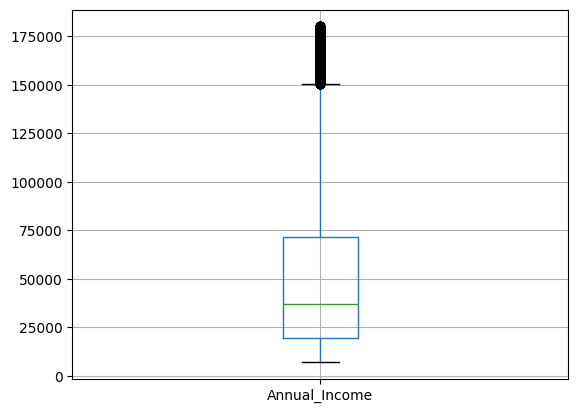

In [4]:
df.boxplot(column='Annual_Income')

# **VISUALIZATIONS**  and Univariate Analysis

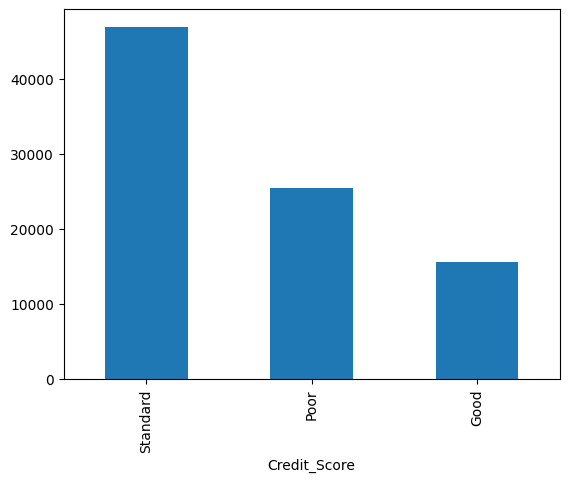

In [5]:
df['Credit_Score'].value_counts().plot(kind='bar')
plt.show()

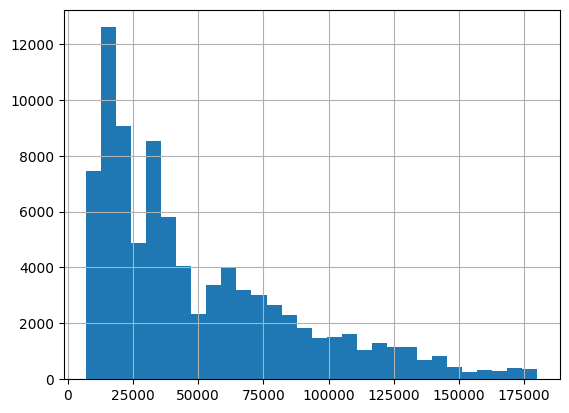

In [6]:
df['Annual_Income'].hist(bins=30)
plt.show()


## Good customers have significantly higher income than Poor customers

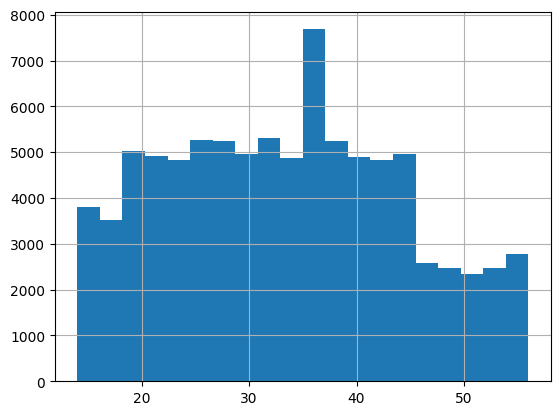

In [7]:
df['Age'].hist(bins=20)
plt.show()


##The customer base is predominantly young to middle aged 20-40 years, with peak around 30-35. Very few customers above 50

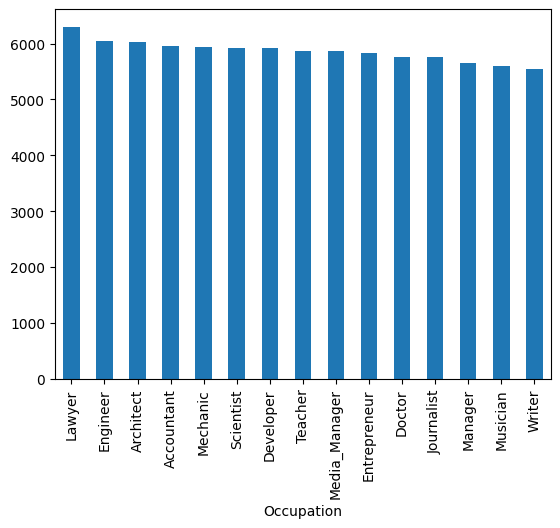

In [8]:
df['Occupation'].value_counts().plot(kind='bar')
plt.show()



##Occupation is fairly evenly distributed across all 15 categories — no single occupation dominates the customer base.

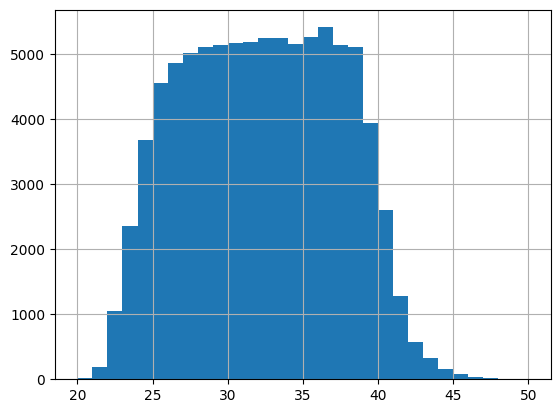

In [9]:
df['Credit_Utilization_Ratio'].hist(bins=30)
plt.show()



##Most customers use around 30-40% of their credit limit — a healthy range. Very few are at extremes.

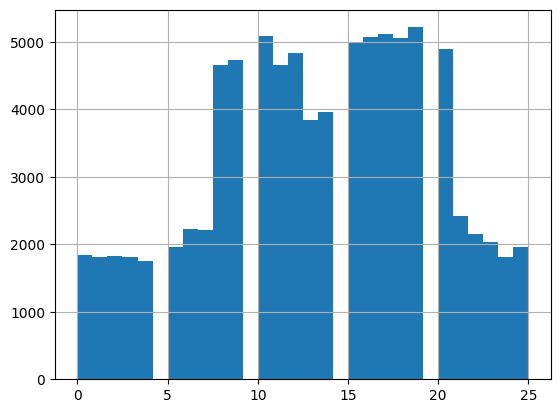

In [10]:
df['Num_of_Delayed_Payment'].hist(bins=30)
plt.show()



##Delayed payments are spread fairly evenly from 0-25 — meaning customers are scattered across all levels of payment behaviour, no clear pattern except there is a spike from 7 to 20 .

# **Bivariate Analysis**

In [11]:
## Understanding if there is relation between Annual_Income and Credit Score

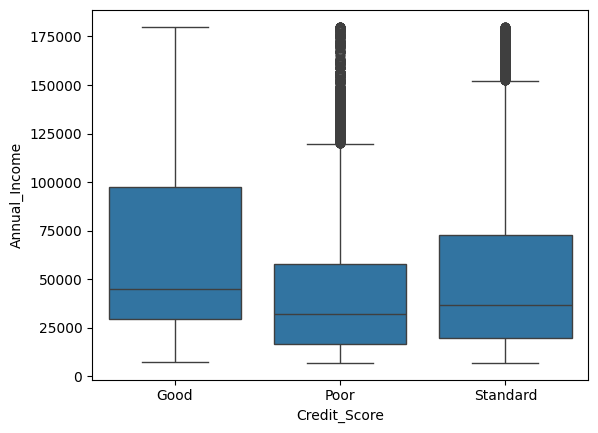

In [12]:
sns.boxplot(x='Credit_Score', y='Annual_Income', data=df)
plt.show()

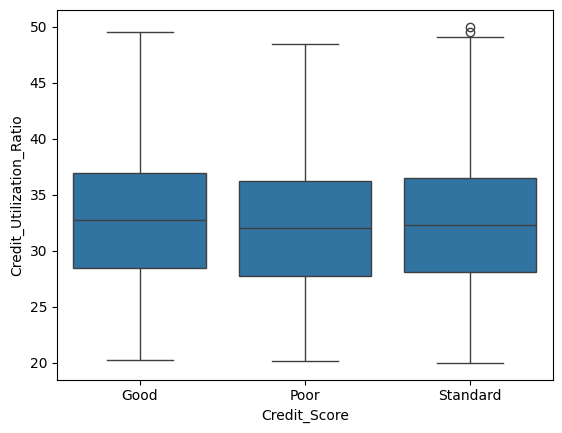

In [13]:
sns.boxplot(x='Credit_Score', y='Credit_Utilization_Ratio', data=df)
plt.show()


## Understanding if there is relation between Credit_Utilization_Ratio and Credit Score

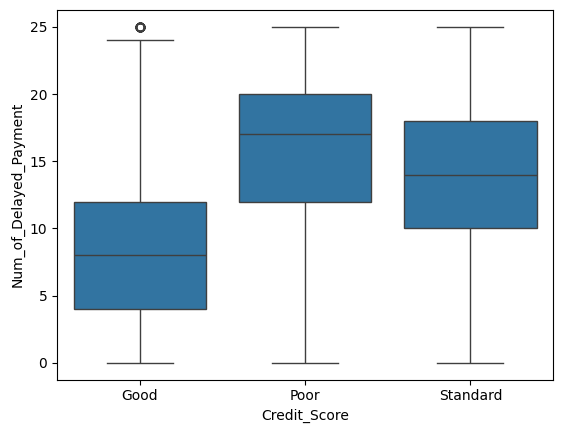

In [14]:
sns.boxplot(x='Credit_Score', y='Num_of_Delayed_Payment', data=df)
plt.show()


## Understanding if there is relation between Num_of_Delayed_Payment and Credit Score

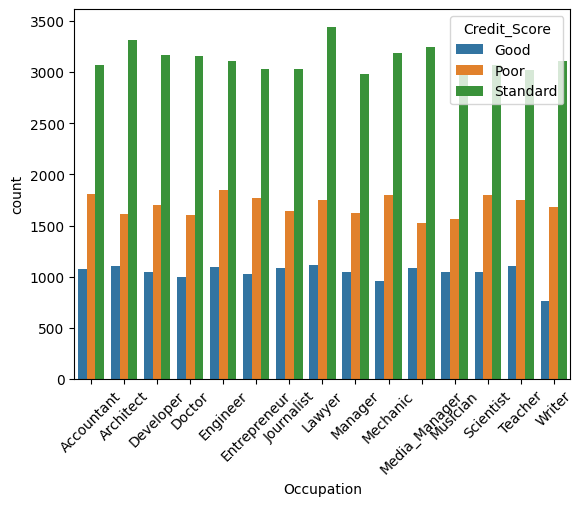

In [15]:
sns.countplot(x='Occupation', hue='Credit_Score', data=df)
plt.xticks(rotation=45)
plt.show()


## Understanding if there is relation between Occupation and Credit Score

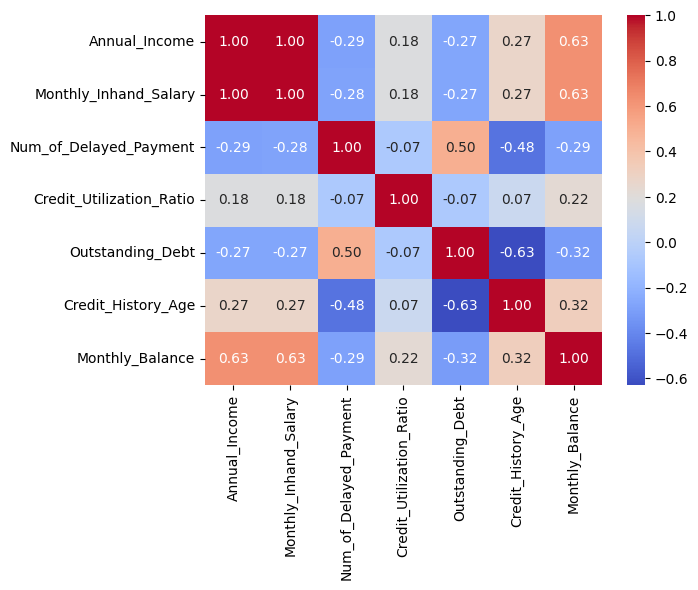

In [16]:
cols = ['Annual_Income', 'Monthly_Inhand_Salary',
        'Num_of_Delayed_Payment', 'Credit_Utilization_Ratio',
        'Outstanding_Debt', 'Credit_History_Age', 'Monthly_Balance']

corr = df[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

Annual Income and Monthly Salary are strongly correlated. Delayed payments show a negative relationship with Monthly Balance  customers who miss payments tend to maintain lower balances

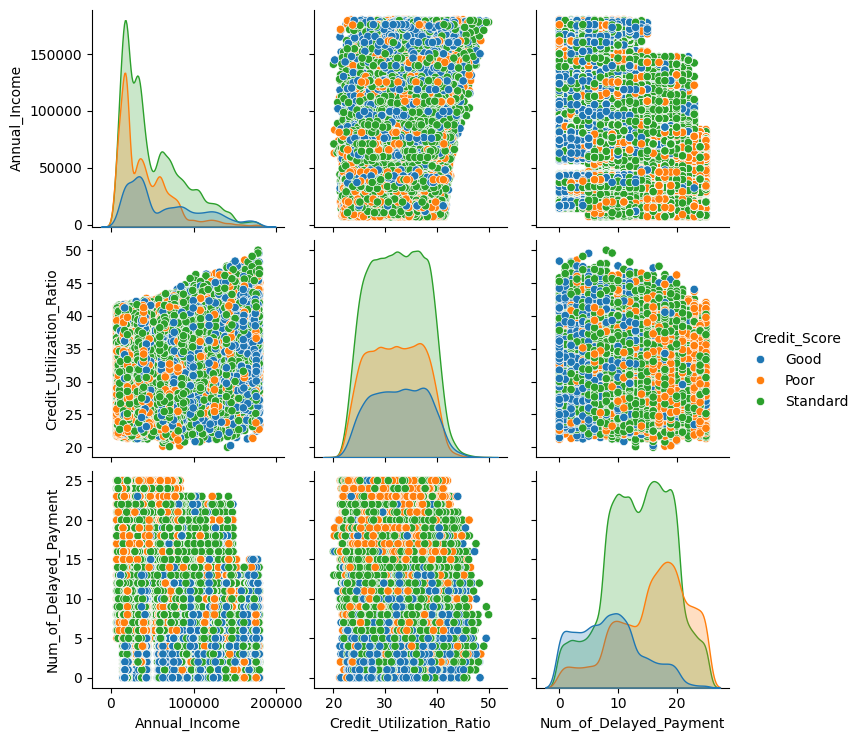

In [17]:
cols = ['Annual_Income', 'Credit_Utilization_Ratio',
        'Num_of_Delayed_Payment', 'Credit_Score']

sns.pairplot(df[cols], hue='Credit_Score')
plt.show()

What are the findings from the analysis?
:1-The data which we worked on was totally relevant to find out what is the relation between different factors in the data , we came across that the major affect was from delayed payments which affected the the score majorly , apart from that the factors such as Annual Income , credit utilization were also contributing but not at that level.

How can Paisabazaar use these findings?
:Paisa bazar can analyze this data and understand their customer base and plan  their loan models accordingly , they can focus on majority age , income and other factors which will help them bring more personalised and precise loan plans to their customer .

What would be your next step beyond EDA?
 :We can go beyond and work on a model which takes these inputs and give prediction for their esitmated crddit score as well we can roughly tell how they can improve their credit score over time .

## Conclusion
Delayed payments is the strongest predictor of Poor credit score. Higher income correlates with Good scores. Paisabazaar should flag customers with 15+ delayed payments as high risk.